# 🧪 Warsztat: Kwantowa Sieć Neuronowa (QNN) w PennyLane

**SGH — Dni Otwarte 2026 | Czas: ~45 min**

---

## Czego się nauczysz?

W tym warsztacie zbudujesz od zera **kwantową sieć neuronową** (Quantum Neural Network), która nauczy się klasyfikować dane. Krok po kroku przejdziemy przez:

1. **Przygotowanie danych** — zbiór `make_moons` z scikit-learn
2. **Kodowanie danych na kubity** — angle encoding
3. **Budowę obwodu kwantowego** — parametryczne bramki kwantowe
4. **Trening modelu** — optymalizacja
5. **Wizualizację wyników** — granice decyzyjne

### Wymagania
```
pip install pennylane numpy matplotlib scikit-learn
```

> 💡 **Wskazówka:** Jeśli nie masz zainstalowanych pakietów, odkomentuj i uruchom pierwszą komórkę kodu poniżej.

In [1]:
# Odkomentuj jeśli potrzebujesz zainstalować pakiety:
# !pip install ipykernel pennylane numpy matplotlib scikit-learn

---
## Część 0: Importy (~1 min)

Zaczynamy od zaimportowania wszystkich potrzebnych bibliotek.

In [2]:
import pennylane as qml
from pennylane import numpy as np  # PennyLane ma własny numpy z autodiff!
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.colors import ListedColormap

# Ustawienia wizualizacji
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['figure.dpi'] = 100

# Seed dla powtarzalności
np.random.seed(42)

print(f"PennyLane version: {qml.__version__}")
print("Wszystko gotowe! 🚀")

PennyLane version: 0.44.1
Wszystko gotowe! 🚀


---
## Część 1: Przygotowanie danych (~5 min)

### Zbiór `make_moons`

Użyjemy syntetycznego zbioru danych w kształcie dwóch "półksiężyców". To klasyczny benchmark do testowania klasyfikatorów — dane **nie są liniowo separowalne**, więc nasz model musi nauczyć się nieliniowej granicy decyzyjnej.

#### Dlaczego akurat ten zbiór?
- Jest **2D** → łatwy do wizualizacji
- Jest **nieliniowy** → pokazuje moc QNN
- Potrzebujemy tylko **2 kubitów** → szybki trening

In [3]:
# Generujemy dane
X, y = make_moons(n_samples=200, noise=0.15, random_state=42)

# Skalujemy cechy do zakresu [0, π] — potrzebne do kodowania kątowego
scaler = MinMaxScaler(feature_range=(0, np.pi))
X_scaled = scaler.fit_transform(X)

# Dzielimy na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42
)

# Konwertujemy na tablice PennyLane numpy (potrzebne do autodiff)
X_train = np.array(X_train, requires_grad=False)
X_test = np.array(X_test, requires_grad=False)
y_train = np.array(y_train, requires_grad=False)
y_test = np.array(y_test, requires_grad=False)

print(f"Zbiór treningowy: {X_train.shape[0]} próbek")
print(f"Zbiór testowy:    {X_test.shape[0]} próbek")
print(f"Cechy:            {X_train.shape[1]} (x₁, x₂)")
print(f"Klasy:            {np.unique(y_train)} (0 = niebieski, 1 = czerwony)")

Zbiór treningowy: 150 próbek
Zbiór testowy:    50 próbek
Cechy:            2 (x₁, x₂)
Klasy:            [0 1] (0 = niebieski, 1 = czerwony)


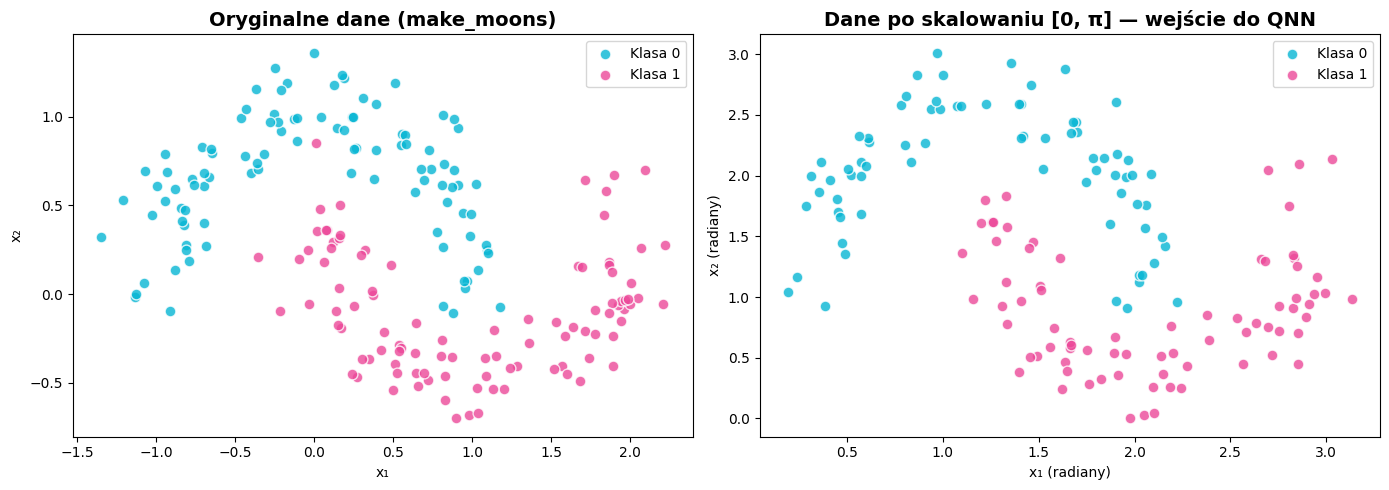


📌 Dane przeskalowane do [0, π] — każda cecha będzie kątem obrotu kubitu!


In [4]:
# Wizualizacja danych
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Oryginalne dane
for cls, color, label in [(0, '#06B6D4', 'Klasa 0'), (1, '#EC4899', 'Klasa 1')]:
    mask = y == cls
    axes[0].scatter(X[mask, 0], X[mask, 1], c=color, label=label, 
                    edgecolors='white', s=60, alpha=0.8)
axes[0].set_title('Oryginalne dane (make_moons)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('x₁')
axes[0].set_ylabel('x₂')
axes[0].legend()

# Przeskalowane dane
for cls, color, label in [(0, '#06B6D4', 'Klasa 0'), (1, '#EC4899', 'Klasa 1')]:
    mask = y_train == cls
    axes[1].scatter(X_train[mask, 0], X_train[mask, 1], c=color, label=label,
                    edgecolors='white', s=60, alpha=0.8)
axes[1].set_title('Dane po skalowaniu [0, π] — wejście do QNN', fontsize=14, fontweight='bold')
axes[1].set_xlabel('x₁ (radiany)')
axes[1].set_ylabel('x₂ (radiany)')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n📌 Dane przeskalowane do [0, π] — każda cecha będzie kątem obrotu kubitu!")

---
## Część 2: Obwód kwantowy — serce QNN (~10 min)

### Architektura naszego QNN

Budujemy obwód kwantowy, który działa jak sieć neuronowa:

```
Dane (x₁,x₂) → Kodowanie kątowe → Warstwy parametryczne → Pomiar → Predykcja
```

#### Krok po kroku:

1. **Kodowanie (Feature Map):** Każdą cechę `x_i` kodujemy jako kąt obrotu bramki `RY` na kubicie `i`
2. **Warstwa parametryczna (Ansatz):** Seria bramek `RX` z **trenowalnym** kątem `θ` + bramki `CNOT` (splątanie)
3. **Pomiar:** Mierzymy wartość oczekiwaną `⟨Z⟩` na pierwszym kubicie 

### Dlaczego te bramki?
- **RY(θ)** — obrót wokół osi Y na sferze Blocha. Zmienia amplitudy stanów |0⟩ i |1⟩
- **CNOT** — bramka splątania. Tworzy korelacje między kubitami
- **⟨Z⟩** — wartość oczekiwana operatora Pauliego Z. Daje liczbę z zakresu [-1, 1]

In [5]:
# Konfiguracja obwodu
n_qubits = 2    # Tyle ile mamy cech
n_layers = 3    # Liczba warstw parametrycznych (głębokość obwodu)

# Tworzymy symulator kwantowy
dev = qml.device('default.qubit', wires=n_qubits)

print(f"Urządzenie: {dev.name}")
print(f"Kubity:     {n_qubits}")
print(f"Warstwy:    {n_layers}")
print(f"\nLiczba parametrów do wytrenowania: {n_qubits * n_layers} kątów θ")

Urządzenie: default.qubit
Kubity:     2
Warstwy:    3

Liczba parametrów do wytrenowania: 6 kątów θ


In [15]:
# ============================================
# DEFINICJA OBWODU KWANTOWEGO (QNode)
# ============================================

@qml.qnode(dev)
def quantum_circuit(weights, x):
    """
    Obwód kwantowy = kwantowa sieć neuronowa.
    
    Parametry:
        weights: tablica kątów θ o wymiarach (n_layers, n_qubits)
        x:       wektor cech jednej próbki (x₁, x₂)
    
    Zwraca:
        Wartość oczekiwana ⟨Z⟩ na kubicie 0 → liczba z [-1, 1]
    """
    
    # --- KROK 1: Kodowanie danych (Feature Encoding) ---
    # Każda cecha x_i staje się kątem obrotu RY na kubicie i
    for i in range(n_qubits):
        qml.RY(x[i], wires=i)
    
    # --- KROK 2: Warstwy parametryczne (Trainable Ansatz) ---
     # ansatz — Rot(phi, theta, omega) + circular CNOT
    for n_l in range(n_layers):
        if n_l % 2 == 0:
            for j in range(n_qubits):
                qml.RZ(weights[n_l][j], wires=j)
            qml.CNOT(wires=[0,1])
            qml.CNOT(wires=[1,0])
        else:
            for j in range(n_qubits):
                qml.RX(weights[n_l][j], wires=j)
            qml.CNOT(wires=[0,1])
            qml.CNOT(wires=[1,0])
            
    
    # --- KROK 3: Pomiar ---
    # Mierzymy wartość oczekiwaną operatora Pauliego Z na kubicie 0
    return qml.expval(qml.PauliZ(0))


print("✅ Obwód zdefiniowany!")
print("\nTeraz zobaczmy jak wygląda nasz obwód...")

✅ Obwód zdefiniowany!

Teraz zobaczmy jak wygląda nasz obwód...


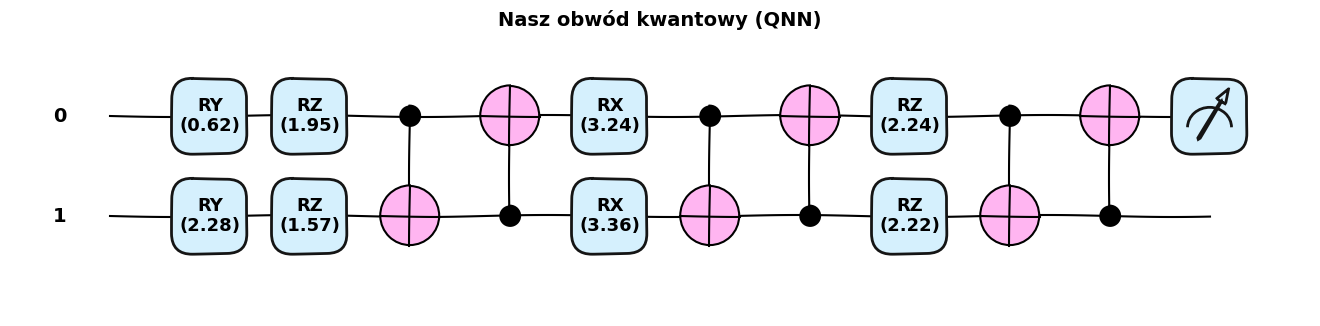


🔍 Struktura obwodu:
   Zielone RY → kodowanie danych (x₁, x₂)
   Niebieskie RY → trenowalny parametr (θ)
   CNOT → splątanie kubitów
   ⟨Z⟩ → pomiar na kubicie 0


In [16]:
# Wizualizacja obwodu
# Tworzymy losowe wagi i przykładowe dane, żeby narysować obwód
example_weights = np.random.uniform(0, 2 * np.pi, (n_layers, n_qubits))
#example_weights = np.random.uniform(0, 2 * np.pi, (n_layers, n_qubits, 3))
example_x = X_train[0]

# Rysujemy obwód
fig, ax = qml.draw_mpl(quantum_circuit, decimals=2, style="pennylane_sketch", level="device" )(example_weights, example_x)
fig.suptitle('Nasz obwód kwantowy (QNN)', fontsize=14, fontweight='bold', y=1.02)
plt.show()

print("\n🔍 Struktura obwodu:")
print("   Zielone RY → kodowanie danych (x₁, x₂)")
print("   Niebieskie RY → trenowalny parametr (θ)")
print("   CNOT → splątanie kubitów")
print("   ⟨Z⟩ → pomiar na kubicie 0")

### 🧠 Ćwiczenie do przemyślenia

> Dlaczego potrzebujemy bramek CNOT? Co by się stało, gdybyśmy mieli tylko bramki RY?
>
> **Odpowiedź:** Bez CNOT każdy kubit działałby niezależnie — nie byłoby splątania. Bramki CNOT pozwalają kubitom "współpracować", tworząc korelacje, których klasyczne bity nie mogą odtworzyć. To jak dodanie warstw ukrytych w sieci neuronowej — pozwala modelować bardziej złożone wzorce!

---
## Część 3: Funkcja kosztu i predykcja (~5 min)

### Od obwodu kwantowego do klasyfikatora

Nasz obwód zwraca wartość `⟨Z⟩ ∈ [-1, 1]`. Musimy ją przekształcić na predykcję klasy:

- Wartość bliska **-1** → klasa **0**
- Wartość bliska **+1** → klasa **1**

Używamy prostego mapowania: `predykcja = (⟨Z⟩ + 1) / 2` → daje nam wartość z [0, 1]

Jako funkcję kosztu używamy **MSE** (Mean Squared Error) — prosta i skuteczna.

In [17]:
def predict_proba(weights, x):
    """Przekształca wynik obwodu ⟨Z⟩ ∈ [-1,1] na prawdopodobieństwo ∈ [0,1]."""
    raw = quantum_circuit(weights, x)
    return (raw + 1) / 2


def predict(weights, x):
    """Zwraca predykcję klasy (0 lub 1)."""
    return 1 if predict_proba(weights, x) >= 0.5 else 0


def cost(weights, X_batch, y_batch):
    predictions = np.array([predict_proba(weights, x) for x in X_batch])
    return np.mean((predictions - y_batch) ** 2)


def accuracy(weights, X_data, y_data):
    """Oblicza dokładność klasyfikacji (accuracy) w %."""
    correct = sum(
        predict(weights, X_data[i]) == y_data[i] 
        for i in range(len(X_data))
    )
    return correct / len(y_data) * 100


# Szybki test z losowymi wagami
test_weights = np.random.uniform(0, 2 * np.pi, (n_layers, n_qubits), requires_grad=True)
test_cost = cost(test_weights, X_train[:10], y_train[:10])
test_acc = accuracy(test_weights, X_train[:10], y_train[:10])

print(f"Test z losowymi wagami:")
print(f"  Koszt (MSE):     {test_cost:.4f}")
print(f"  Dokładność:      {test_acc:.0f}%")
print(f"\n📌 Losowe wagi → ~50% dokładności (jak rzut monetą).")
print(f"   Po treningu powinno być znacznie lepiej!")

Test z losowymi wagami:
  Koszt (MSE):     0.1867
  Dokładność:      80%

📌 Losowe wagi → ~50% dokładności (jak rzut monetą).
   Po treningu powinno być znacznie lepiej!


---
## Część 4: Trening QNN (~15 min)

### Jak trenujemy kwantową sieć neuronową?

Proces jest **identyczny** jak w klasycznym ML:

1. Forward pass — oblicz predykcje z aktualnych wag
2. Oblicz koszt (loss)
3. Oblicz gradienty (∂loss/∂θ) — PennyLane robi to automatycznie!
4. Zaktualizuj wagi: `θ_new = θ_old - lr × gradient`
5. Powtórz

### Magia PennyLane: Parameter Shift Rule

PennyLane oblicza gradienty obwodu kwantowego za pomocą **parameter shift rule**. Zamiast backpropagation, wykonuje obwód dwa razy z minimalnie zmienionymi parametrami i z różnicy wyników oblicza gradient. Elegancko i dokładnie! ✨

### Mini-batch training

Żeby trening nie trwał zbyt długo na symulatorze, użyjemy **mini-batchy** — w każdej epoce losujemy podzbiór danych.

In [18]:
# ============================================
# KONFIGURACJA TRENINGU
# ============================================

n_epochs = 30          # Liczba epok
batch_size = 20        # Rozmiar mini-batcha
learning_rate = 0.3    # Współczynnik uczenia

# Inicjalizacja wag — losowe kąty z [0, 2π]
weights = np.random.uniform(0, 2 * np.pi, (n_layers, n_qubits), requires_grad=True)

# Optymalizator — Adam (ten sam co w PyTorch/TensorFlow!)
opt = qml.AdamOptimizer(stepsize=learning_rate)

print("Konfiguracja treningu:")
print(f"  Epoki:          {n_epochs}")
print(f"  Batch size:     {batch_size}")
print(f"  Learning rate:  {learning_rate}")
print(f"  Optymalizator:  Adam")
print(f"  Parametry:      {weights.size} kątów θ")
print(f"\nPoczątkowe wagi (radiany):")
print(weights.round(3))

Konfiguracja treningu:
  Epoki:          30
  Batch size:     20
  Learning rate:  0.3
  Optymalizator:  Adam
  Parametry:      6 kątów θ

Początkowe wagi (radiany):
[[2.227 3.177]
 [5.913 5.506]
 [0.644 2.468]]


In [19]:
# ============================================
# PĘTLA TRENINGOWA
# ============================================

# Listy do śledzenia postępów
history = {
    'cost': [],
    'train_acc': [],
    'test_acc': []
}

print("🚀 Start treningu!")
print("=" * 65)
print(f"{'Epoka':>6} | {'Koszt':>8} | {'Acc train':>10} | {'Acc test':>10} | Status")
print("-" * 65)

for epoch in range(n_epochs):
    
    # --- Mini-batch: losujemy podzbiór danych ---
    batch_idx = np.random.choice(len(X_train), batch_size, replace=False)
    X_batch = X_train[batch_idx]
    y_batch = y_train[batch_idx]
    
    # --- Krok optymalizacji ---
    # PennyLane automatycznie oblicza gradienty i aktualizuje wagi!
    weights, loss_val = opt.step_and_cost(
    lambda w, _X=X_batch, _y=y_batch: cost(w, _X, _y),
    weights
)
    
    # --- Ewaluacja co 5 epok ---
    if (epoch + 1) % 5 == 0 or epoch == 0:
        train_acc = accuracy(weights, X_train[:50], y_train[:50])  # podzbiór dla szybkości
        test_acc = accuracy(weights, X_test, y_test)
        
        status = "📈" if len(history['test_acc']) == 0 or test_acc > max(history['test_acc']) else "  "
        
        history['cost'].append(float(loss_val))
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        
        print(f"  {epoch+1:4d} | {float(loss_val):8.4f} | {train_acc:8.1f}%  | {test_acc:8.1f}%  | {status}")

print("-" * 65)
print(f"\n✅ Trening zakończony!")
print(f"   Najlepsza dokładność na zbiorze testowym: {max(history['test_acc']):.1f}%")

🚀 Start treningu!
 Epoka |    Koszt |  Acc train |   Acc test | Status
-----------------------------------------------------------------
     1 |   0.4557 |     34.0%  |     38.0%  | 📈
     5 |   0.2231 |     68.0%  |     68.0%  | 📈
    10 |   0.1442 |     70.0%  |     72.0%  | 📈
    15 |   0.1292 |     68.0%  |     70.0%  |   
    20 |   0.1966 |     68.0%  |     66.0%  |   
    25 |   0.2040 |     72.0%  |     66.0%  |   
    30 |   0.1769 |     64.0%  |     66.0%  |   
-----------------------------------------------------------------

✅ Trening zakończony!
   Najlepsza dokładność na zbiorze testowym: 72.0%


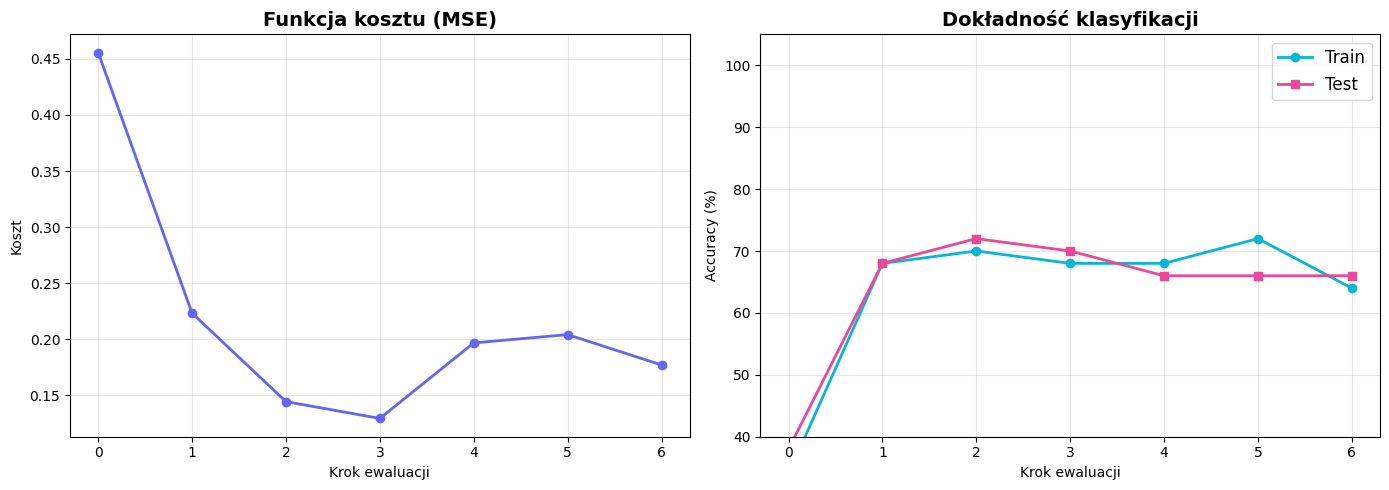

In [21]:
# Wizualizacja procesu treningu
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

steps = range(len(history['cost']))

# Wykres kosztu
axes[0].plot(steps, history['cost'], 'o-', color='#6366F1', linewidth=2, markersize=6)
axes[0].set_title('Funkcja kosztu (MSE)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Krok ewaluacji')
axes[0].set_ylabel('Koszt')
axes[0].grid(True, alpha=0.3)

# Wykres dokładności
axes[1].plot(steps, history['train_acc'], 'o-', color='#06B6D4', linewidth=2, markersize=6, label='Train')
axes[1].plot(steps, history['test_acc'], 's-', color='#EC4899', linewidth=2, markersize=6, label='Test')
axes[1].set_title('Dokładność klasyfikacji', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Krok ewaluacji')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([40, 105])

plt.tight_layout()
plt.show()

---
## Część 5: Wizualizacja wyników (~5 min)

Najciekawsza część! Narysujemy **granicę decyzyjną** — czyli jak nasz QNN dzieli przestrzeń cech na dwie klasy. Porównamy wyniki z prostym klasycznym klasyfikatorem.

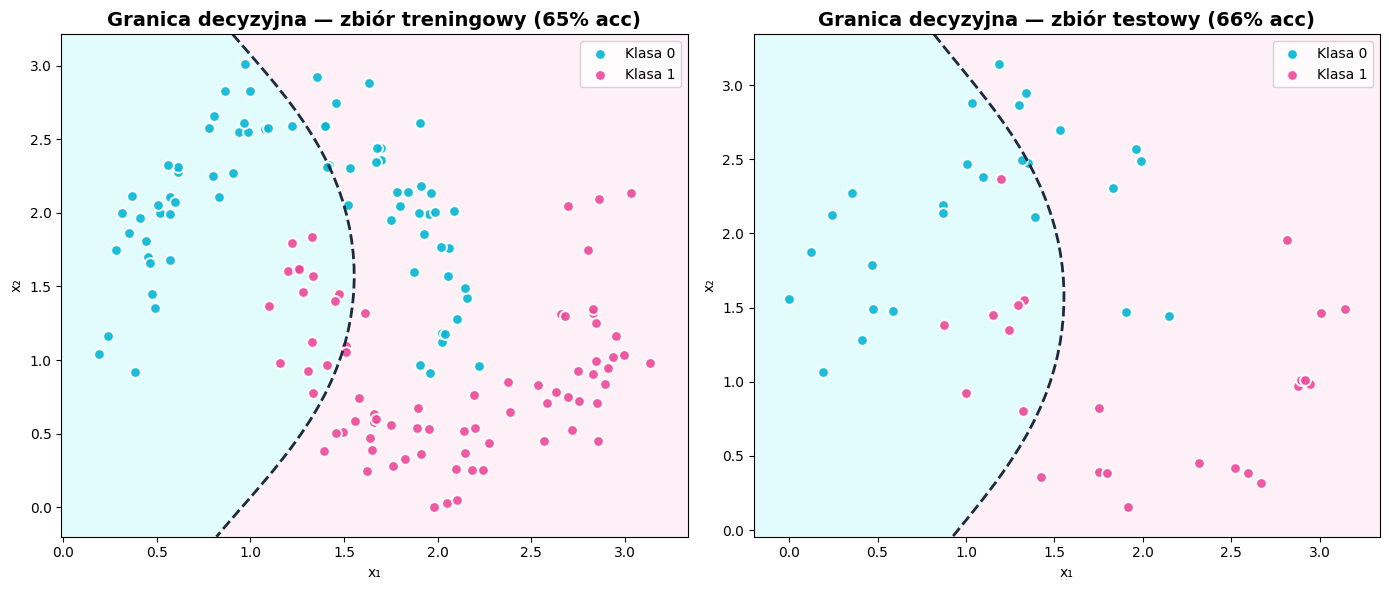


🎉 Nasz QNN z zaledwie 18 parametrami nauczył się nieliniowej granicy decyzyjnej!


In [22]:
# ============================================
# GRANICA DECYZYJNA QNN
# ============================================

def plot_decision_boundary(weights, X_data, y_data, title="QNN", ax=None):
    """Rysuje granicę decyzyjną QNN na siatce punktów."""
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    
    # Tworzymy siatkę punktów
    margin = 0.2
    x_min, x_max = X_data[:, 0].min() - margin, X_data[:, 0].max() + margin
    y_min, y_max = X_data[:, 1].min() - margin, X_data[:, 1].max() + margin
    
    resolution = 40  # Gęstość siatki (więcej = ładniej, ale wolniej)
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, resolution),
        np.linspace(y_min, y_max, resolution)
    )
    
    # Predykcja dla każdego punktu siatki
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = np.array([predict_proba(weights, point) for point in grid_points])
    Z = Z.reshape(xx.shape)
    
    # Rysujemy mapę cieplną i dane
    cmap_bg = ListedColormap(['#CFFAFE', '#FCE7F3'])
    cmap_pts = ListedColormap(['#06B6D4', '#EC4899'])
    
    ax.contourf(xx, yy, Z, levels=[0, 0.5, 1], cmap=cmap_bg, alpha=0.6)
    ax.contour(xx, yy, Z, levels=[0.5], colors=['#1E293B'], linewidths=2, linestyles='dashed')
    
    for cls, color, label in [(0, '#06B6D4', 'Klasa 0'), (1, '#EC4899', 'Klasa 1')]:
        mask = y_data == cls
        ax.scatter(X_data[mask, 0], X_data[mask, 1], c=color, label=label,
                   edgecolors='white', s=60, alpha=0.9, linewidths=1.5)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('x₁')
    ax.set_ylabel('x₂')
    ax.legend(loc='upper right')
    
    return ax


# Rysujemy granicę decyzyjną dla zbioru treningowego i testowego
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_decision_boundary(weights, X_train, y_train, 
                       title=f'Granica decyzyjna — zbiór treningowy ({accuracy(weights, X_train, y_train):.0f}% acc)', 
                       ax=axes[0])
plot_decision_boundary(weights, X_test, y_test, 
                       title=f'Granica decyzyjna — zbiór testowy ({accuracy(weights, X_test, y_test):.0f}% acc)', 
                       ax=axes[1])

plt.tight_layout()
plt.show()

print("\n🎉 Nasz QNN z zaledwie 18 parametrami nauczył się nieliniowej granicy decyzyjnej!")

---
## Część 6: Analiza i wytrenowane parametry (~3 min)

Zobaczmy, czego nauczył się nasz obwód kwantowy — jakie kąty θ znalazł optymalizator.

In [23]:
weights

tensor([[1.64601862, 7.28804679],
        [7.19027765, 2.52419999],
        [0.64445352, 2.46760004]], requires_grad=True)

---
## Część 7: Eksperymenty — Twoja kolej! (~15 min)

Teraz Twoja kolej na eksperymenty! Poniżej kilka pomysłów do przetestowania.

### 🔬 Eksperyment 1: zrealizuj klasyczną sieć neuronową z kilkoma warstwami ukrytymi

In [14]:
# 🔬 EKSPERYMENT 1: 
from sklearn.neural_network import MLPClassifier

# Tworzymy klasyczną sieć neuronową (ANN)

classic_model = MLPClassifier(hidden_layer_sizes=(____, _____), max_iter=1000, random_state=42)

# Trening
classic_model.fit(X_train, y_train)

# Wyniki
classic_acc = classic_model.score(X_test, y_test) * 100
print(f"🧠 Dokładność klasycznej sieci (ANN): {classic_acc:.1f}%")

NameError: name '____' is not defined

### 🔬 Eksperyment 2: Wygeneruj własny model QNN 

\* lub zobacz co się stanie gdy zwiększymy liczbę parametrów i dodamy splątanie.


In [24]:
# ============================================
# DEFINICJA OBWODU KWANTOWEGO (QNode)
# ============================================

@qml.qnode(dev)
def quantum_circuit(weights, x):
    
    qml.AngleEmbedding(x, wires=range(n_qubits), rotation='Y')
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return qml.expval(qml.PauliZ(0))


print("✅ Obwód zdefiniowany!")
print("\nTeraz zobaczmy jak wygląda nasz obwód...")

✅ Obwód zdefiniowany!

Teraz zobaczmy jak wygląda nasz obwód...


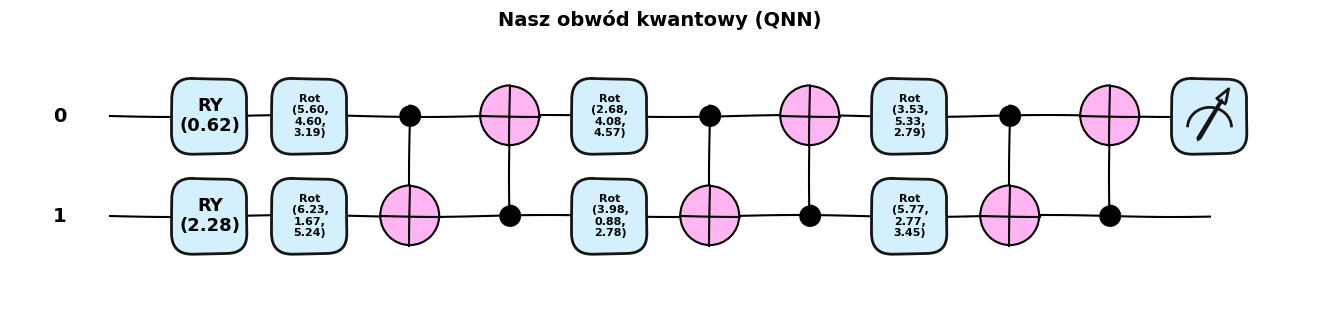


🔍 Struktura obwodu:
   Zielone RY → kodowanie danych (x₁, x₂)
   Niebieskie RY → trenowalny parametr (θ)
   CNOT → splątanie kubitów
   ⟨Z⟩ → pomiar na kubicie 0


In [25]:
# Wizualizacja obwodu
# Tworzymy losowe wagi i przykładowe dane, żeby narysować obwód
example_weights = np.random.uniform(0, 2 * np.pi, (n_layers, n_qubits, 3))
example_x = X_train[0]

# Rysujemy obwód
fig, ax = qml.draw_mpl(quantum_circuit, decimals=2, style="pennylane_sketch", level="device" )(example_weights, example_x)
fig.suptitle('Nasz obwód kwantowy (QNN)', fontsize=14, fontweight='bold', y=1.02)
plt.show()

print("\n🔍 Struktura obwodu:")
print("   Zielone RY → kodowanie danych (x₁, x₂)")
print("   Niebieskie RY → trenowalny parametr (θ)")
print("   CNOT → splątanie kubitów")
print("   ⟨Z⟩ → pomiar na kubicie 0")

In [27]:
# ============================================
# KONFIGURACJA TRENINGU
# ============================================

n_epochs = 50          # Liczba epok
batch_size = 20        # Rozmiar mini-batcha
learning_rate = 0.3    # Współczynnik uczenia

# Inicjalizacja wag — losowe kąty z [0, 2π]
weights = np.random.uniform(0, 2 * np.pi, (n_layers, n_qubits, 3), requires_grad=True)

# Optymalizator — Adam (ten sam co w PyTorch/TensorFlow!)
opt = qml.AdamOptimizer(stepsize=learning_rate)

print("Konfiguracja treningu:")
print(f"  Epoki:          {n_epochs}")
print(f"  Batch size:     {batch_size}")
print(f"  Learning rate:  {learning_rate}")
print(f"  Optymalizator:  Adam")
print(f"  Parametry:      {weights.size} kątów θ")
print(f"\nPoczątkowe wagi (radiany):")
print(weights.round(3))

Konfiguracja treningu:
  Epoki:          50
  Batch size:     20
  Learning rate:  0.3
  Optymalizator:  Adam
  Parametry:      18 kątów θ

Początkowe wagi (radiany):
[[[1.693 5.576 0.863]
  [2.113 3.687 0.647]]

 [[4.588 2.433 4.929]
  [3.097 1.136 4.617]]

 [[1.584 3.084 0.475]
  [3.882 4.184 2.379]]]


In [28]:
# ============================================
# PĘTLA TRENINGOWA
# ============================================

# Listy do śledzenia postępów
history = {
    'cost': [],
    'train_acc': [],
    'test_acc': []
}

print("🚀 Start treningu!")
print("=" * 65)
print(f"{'Epoka':>6} | {'Koszt':>8} | {'Acc train':>10} | {'Acc test':>10} | Status")
print("-" * 65)

for epoch in range(n_epochs):
    
    # --- Mini-batch: losujemy podzbiór danych ---
    batch_idx = np.random.choice(len(X_train), batch_size, replace=False)
    X_batch = X_train[batch_idx]
    y_batch = y_train[batch_idx]
    
    # --- Krok optymalizacji ---
    # PennyLane automatycznie oblicza gradienty i aktualizuje wagi!
    weights, loss_val = opt.step_and_cost(
    lambda w, _X=X_batch, _y=y_batch: cost(w, _X, _y),
    weights
)
    
    # --- Ewaluacja co 5 epok ---
    if (epoch + 1) % 5 == 0 or epoch == 0:
        train_acc = accuracy(weights, X_train[:50], y_train[:50])  # podzbiór dla szybkości
        test_acc = accuracy(weights, X_test, y_test)
        
        status = "📈" if len(history['test_acc']) == 0 or test_acc > max(history['test_acc']) else "  "
        
        history['cost'].append(float(loss_val))
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        
        print(f"  {epoch+1:4d} | {float(loss_val):8.4f} | {train_acc:8.1f}%  | {test_acc:8.1f}%  | {status}")

print("-" * 65)
print(f"\n✅ Trening zakończony!")
print(f"   Najlepsza dokładność na zbiorze testowym: {max(history['test_acc']):.1f}%")

🚀 Start treningu!
 Epoka |    Koszt |  Acc train |   Acc test | Status
-----------------------------------------------------------------
     1 |   0.2233 |     80.0%  |     76.0%  | 📈
     5 |   0.1072 |     86.0%  |     88.0%  | 📈
    10 |   0.1395 |     86.0%  |     86.0%  |   
    15 |   0.1226 |     86.0%  |     82.0%  |   
    20 |   0.1113 |     86.0%  |     80.0%  |   
    25 |   0.0815 |     86.0%  |     92.0%  | 📈
    30 |   0.0775 |     86.0%  |     80.0%  |   
    35 |   0.0692 |     84.0%  |     82.0%  |   
    40 |   0.1219 |     84.0%  |     80.0%  |   
    45 |   0.1513 |     90.0%  |     86.0%  |   
    50 |   0.0764 |     84.0%  |     84.0%  |   
-----------------------------------------------------------------

✅ Trening zakończony!
   Najlepsza dokładność na zbiorze testowym: 92.0%


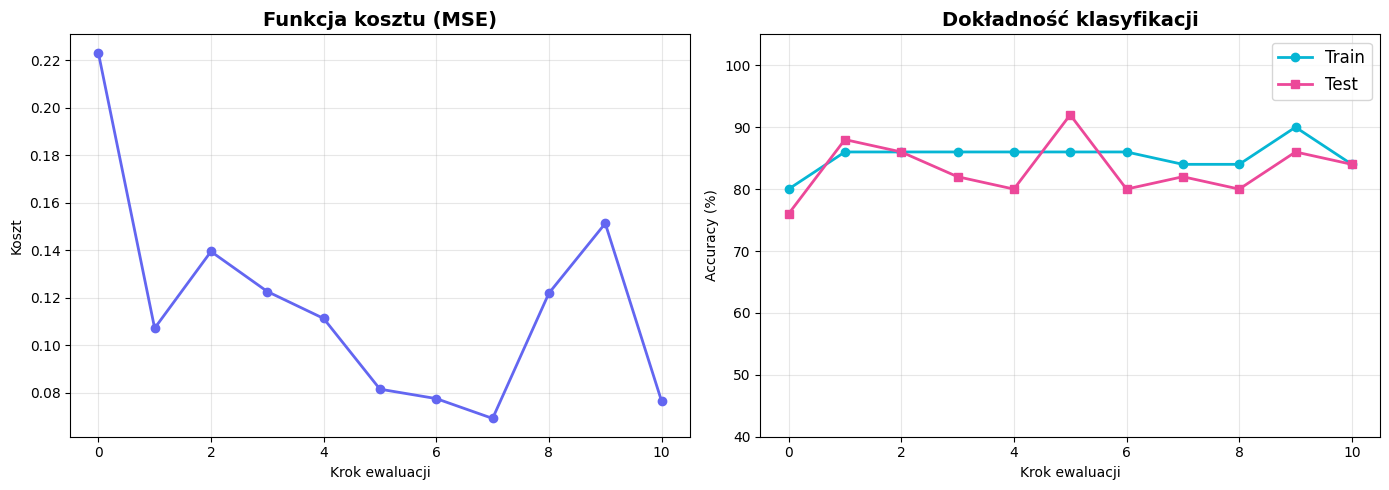

In [29]:
# Wizualizacja procesu treningu
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

steps = range(len(history['cost']))

# Wykres kosztu
axes[0].plot(steps, history['cost'], 'o-', color='#6366F1', linewidth=2, markersize=6)
axes[0].set_title('Funkcja kosztu (MSE)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Krok ewaluacji')
axes[0].set_ylabel('Koszt')
axes[0].grid(True, alpha=0.3)

# Wykres dokładności
axes[1].plot(steps, history['train_acc'], 'o-', color='#06B6D4', linewidth=2, markersize=6, label='Train')
axes[1].plot(steps, history['test_acc'], 's-', color='#EC4899', linewidth=2, markersize=6, label='Test')
axes[1].set_title('Dokładność klasyfikacji', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Krok ewaluacji')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([40, 105])

plt.tight_layout()
plt.show()

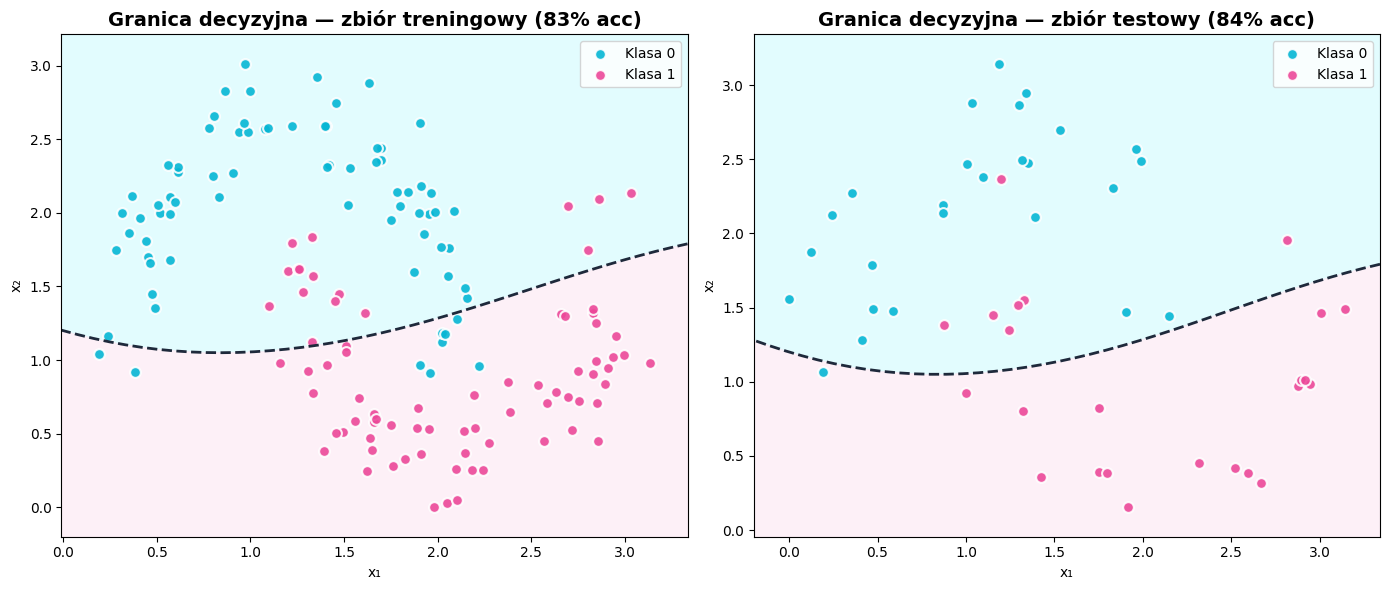


🎉 Nasz QNN z zaledwie 18 parametrami nauczył się nieliniowej granicy decyzyjnej!


In [30]:
# ============================================
# GRANICA DECYZYJNA QNN
# ============================================

# Rysujemy granicę decyzyjną dla zbioru treningowego i testowego
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_decision_boundary(weights, X_train, y_train, 
                       title=f'Granica decyzyjna — zbiór treningowy ({accuracy(weights, X_train, y_train):.0f}% acc)', 
                       ax=axes[0])
plot_decision_boundary(weights, X_test, y_test, 
                       title=f'Granica decyzyjna — zbiór testowy ({accuracy(weights, X_test, y_test):.0f}% acc)', 
                       ax=axes[1])

plt.tight_layout()
plt.show()

print("\n🎉 Nasz QNN z zaledwie 18 parametrami nauczył się nieliniowej granicy decyzyjnej!")

---
## Podsumowanie

### Co zrobiliśmy w tym warsztacie?

| Krok | Klasyczne ML | Kwantowe ML |
|------|-------------|-------------|
| Dane | `make_moons` | `make_moons` (to samo!) |
| Model | Sieć neuronowa (warstwy Dense) | Obwód kwantowy (bramki RY + CNOT) |
| Parametry | Wagi neuronów (setki-tysiące) | Kąty obrotu θ (**tylko 6!**) |
| Trening | Backpropagation | Parameter shift rule |
| Optymalizator | Adam, SGD | Adam, SGD (te same!) |
| Framework | PyTorch, TensorFlow | **PennyLane** |

### Kluczowe wnioski

1. **QNN działa jak sieć neuronowa** — ta sama pętla: forward → loss → gradient → update
2. **Kodowanie kątowe** zamienia dane klasyczne na stany kubitów
3. **Splątanie (CNOT) jest kluczowe** — bez niego kubity nie współpracują
4. **Mało parametrów** — nasz QNN ma 6 parametrów vs setki w klasycznym modelu
5. **PennyLane** sprawia, że quantum ML jest równie łatwe jak klasyczne ML

### Co dalej?

- 📚 **PennyLane demos:** [pennylane.ai/qml/demos](https://pennylane.ai/qml/demos)
- 🎓 **Xanadu Codebook:** [codebook.xanadu.ai](https://codebook.xanadu.ai)
- 🔬 **IBM Quantum Learning:** [learning.quantum.ibm.com](https://learning.quantum.ibm.com)
- 📖 **Książka:** O. Ezratty, *Understanding Quantum Technologies* (darmowa!)
- 🏃 **Następny krok:** Spróbuj z prawdziwym komputerem kwantowym IBM → `qml.device('qiskit.ibmq', ...)`

In [ ]:
# Końcowy easter egg 🐱
print("\n" + "═" * 50)
print("  🐱 Gratulacje! Zbudowałeś/aś swój pierwszy")
print("     kwantowy klasyfikator!")
print("")
print("     Pamiętaj: kot Schrödingera byłby dumny.")
print("     (Albo nie. Albo jedno i drugie.)")
print("═" * 50)